# 🛰️ Можно ли верить вашей модели? — Объём трафика IoT-потока
### Регрессия от EDA до честного вердикта · YDL 2026 · Неделя 2, День 2

**Задача (одной фразой):** по «поведенческому отпечатку» сетевого потока (число пакетов, тайминги,
флаги, протокол) предсказать **сколько байт он перенесёт** — *не считая сами байты*.

**Для кого:** инженеру сети / SOC-аналитику — для планирования ёмкости канала и детекта объёмных
аномалий (DDoS, эксфильтрация), где поток внезапно «тяжелее», чем подсказывает его поведение.

**Данные:** UCI **RT-IoT2022** (id 942) — 123 117 реальных сетевых потоков IoT-стенда, 83 признака.
Цель `flow_pkts_payload.tot` — суммарный объём полезной нагрузки потока в байтах (**непрерывная** величина).

**Линия дня:** не выдать красивый R², а доказать — где модели можно верить, а где она врёт.

## 0. Загрузка

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RS = 42

# Датасет получен один раз через ucimlrepo(id=942) и сохранён в rt_iot2022.csv.
raw  = pd.read_csv("rt_iot2022.csv")
full = raw.drop_duplicates()
df   = full.sample(40000, random_state=RS).reset_index(drop=True)   # представительная выборка
print(f"Сырых строк: {len(raw)} | дублей удалено: {len(raw)-len(full)} | рабочая выборка: {df.shape}")
df[["proto", "service", "fwd_pkts_tot", "bwd_pkts_tot",
    "flow_duration", "flow_pkts_payload.tot"]].head()

Сырых строк: 123117 | дублей удалено: 5195 | рабочая выборка: (40000, 84)


,proto,service,fwd_pkts_tot,bwd_pkts_tot,flow_duration,flow_pkts_payload.tot
0,tcp,-,1,1,0.000001,120
1,udp,-,490,355,51.527887,483067
2,tcp,-,1,0,0.000000,120
3,tcp,-,1,1,0.000004,120
4,tcp,-,1,1,0.000001,120


## 1. Данные и задача
Цель `flow_pkts_payload.tot` непрерывная (байты) — это регрессия, не классификация.
Признаки — поведение потока: счётчики пакетов, межпакетные интервалы, TCP-флаги, размеры окон,
протокол/сервис. Чувствительные поля (IP, исходный порт) и сам ответ (байты payload) не используем.

In [2]:
TARGET = "flow_pkts_payload.tot"
print("Пропусков в выборке:", int(df.isna().sum().sum()))
print("Состав трафика (Attack_type) — данные сильно несбалансированы:")
print(df["Attack_type"].value_counts(normalize=True).mul(100).round(1).head(5).to_string())
df[[TARGET, "fwd_pkts_tot", "bwd_pkts_tot", "flow_duration"]].describe().round(2)

Пропусков в выборке: 0
Состав трафика (Attack_type) — данные сильно несбалансированы:
Attack_type
DOS_SYN_Hping     76.6
ARP_poisioning     6.4
Thing_Speak        6.4
MQTT_Publish       3.5
NMAP_UDP_SCAN      2.1


,flow_pkts_payload.tot,fwd_pkts_tot,bwd_pkts_tot,flow_duration
count,40000.00,40000.00,40000.00,40000.00
mean,831.17,2.20,1.95,3.29
std,68334.13,16.51,50.87,74.24
min,0.00,0.00,0.00,0.00
25%,120.00,1.00,1.00,0.00
50%,120.00,1.00,1.00,0.00
75%,120.00,1.00,1.00,0.00
max,13610585.00,1887.00,10112.00,9433.89


## 2. EDA — распределение цели, корреляции, ловушки

Цель в байтах: медиана=120, среднее=831, max=13610585, скос=197.6


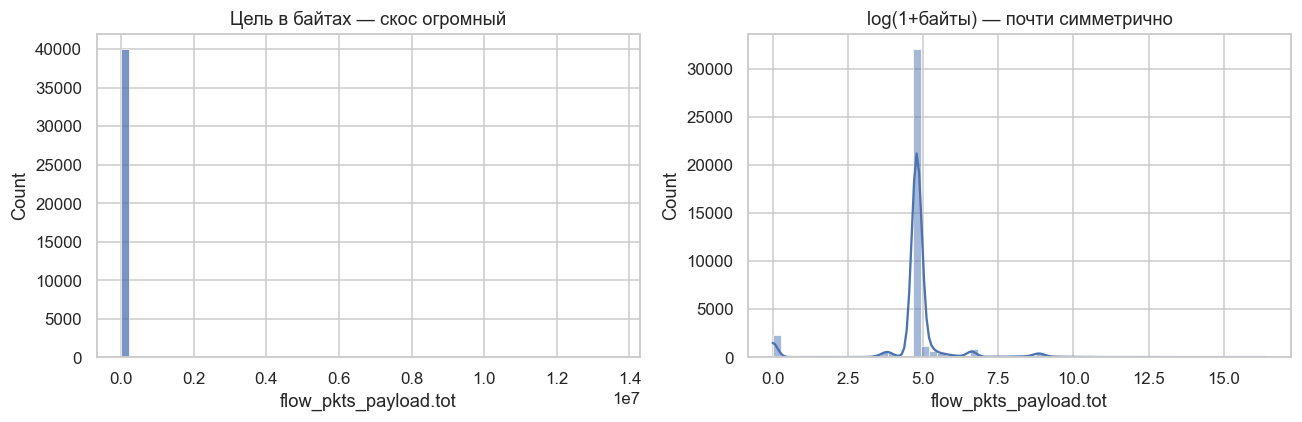

In [3]:
print(f"Цель в байтах: медиана={df[TARGET].median():.0f}, среднее={df[TARGET].mean():.0f}, "
      f"max={df[TARGET].max():.0f}, скос={df[TARGET].skew():.1f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], bins=60, ax=ax[0]); ax[0].set_title("Цель в байтах — скос огромный")
sns.histplot(np.log1p(df[TARGET]), bins=60, kde=True, ax=ax[1])
ax[1].set_title("log(1+байты) — почти симметрично")
plt.tight_layout()

**🎭 Ловушка №1 — скос.** Цель скошена в сотни раз (редкие потоки в мегабайты, большинство — десятки байт).
В исходной шкале регрессия гналась бы за гигантами и врала на массе. **Решение:** учим в шкале
`y = log(1+bytes)`, а в вердикте возвращаемся к байтам. По той же причине логарифмируем и скошенные
**признаки** (счётчики пакетов, длительность, скорости).

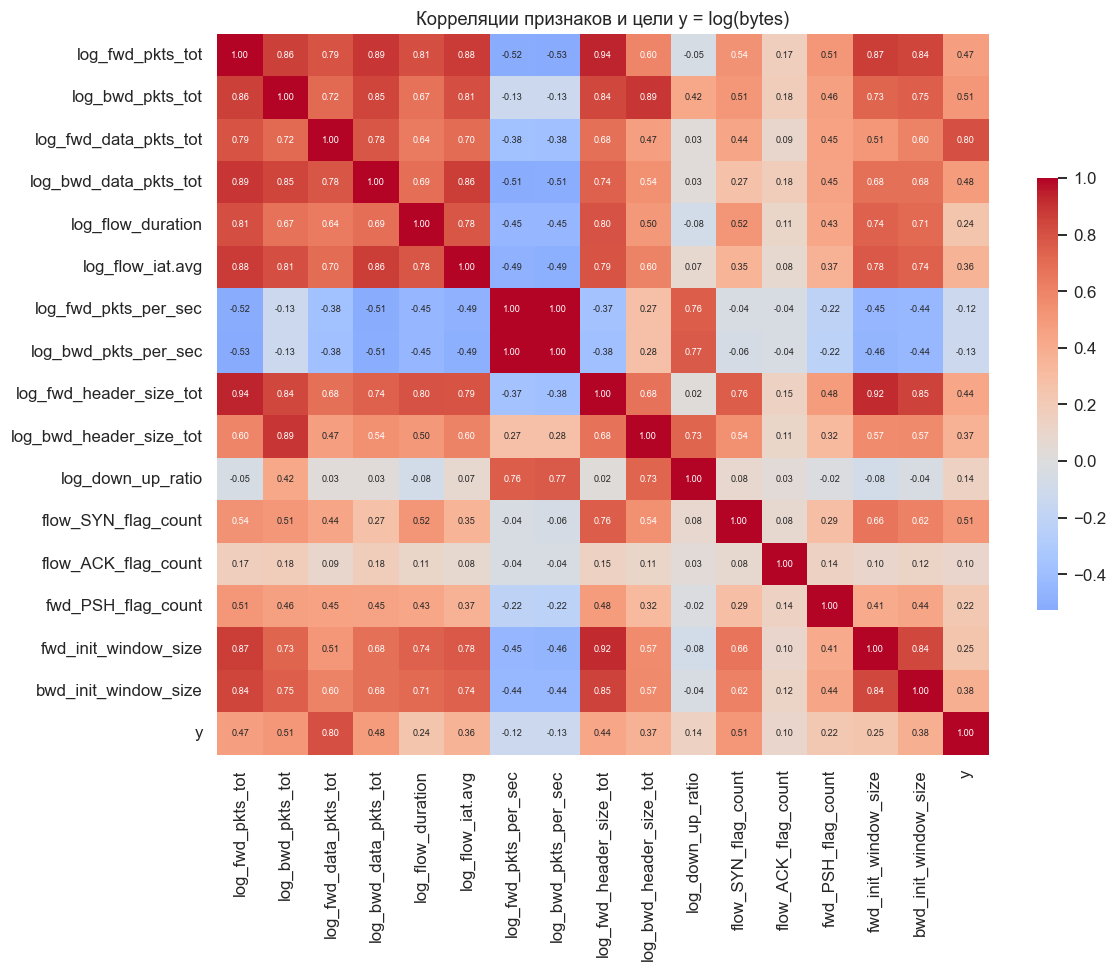

In [4]:
df["y"] = np.log1p(df[TARGET])

# Скошенные признаки -> log1p (числа без отрицательных значений)
logf = ["fwd_pkts_tot", "bwd_pkts_tot", "fwd_data_pkts_tot", "bwd_data_pkts_tot",
        "flow_duration", "flow_iat.avg", "fwd_pkts_per_sec", "bwd_pkts_per_sec",
        "fwd_header_size_tot", "bwd_header_size_tot", "down_up_ratio"]
for c in logf:
    df["log_" + c] = np.log1p(df[c].clip(lower=0))

num_log = ["log_" + c for c in logf]
asis    = ["flow_SYN_flag_count", "flow_ACK_flag_count", "fwd_PSH_flag_count",
           "fwd_init_window_size", "bwd_init_window_size"]

corr = df[num_log + asis + ["y"]].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 6}, cbar_kws={"shrink": .6})
plt.title("Корреляции признаков и цели y = log(bytes)"); plt.tight_layout()

Топ-3 предиктора по |корреляции| с y: ['log_fwd_data_pkts_tot', 'flow_SYN_flag_count', 'log_bwd_pkts_tot']


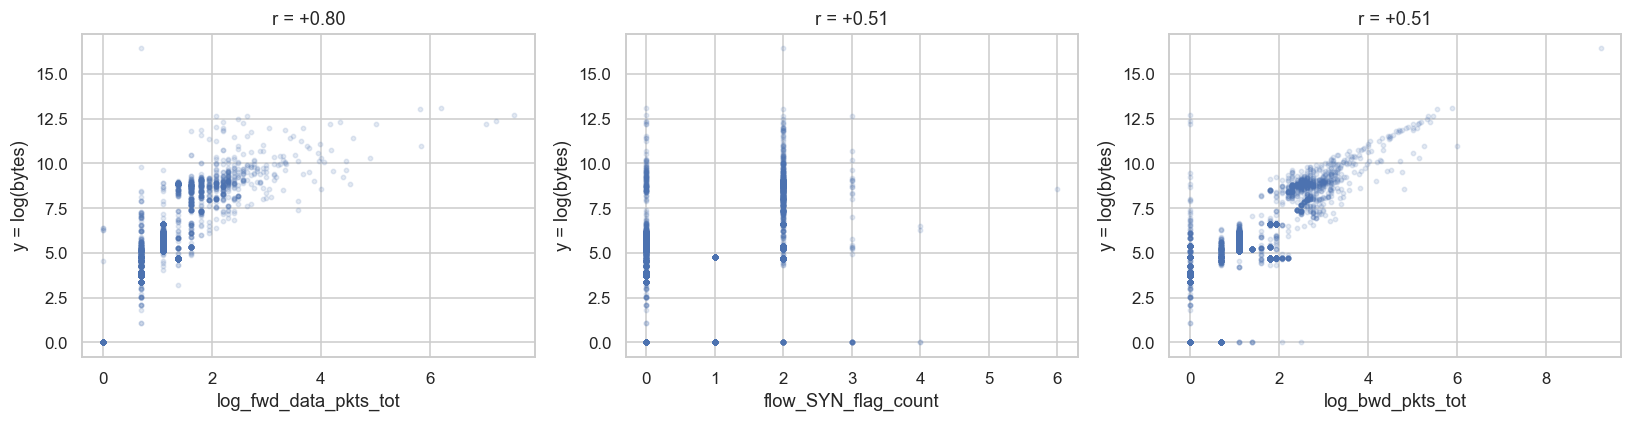

In [5]:
top3 = corr["y"].drop("y").abs().sort_values(ascending=False).head(3).index.tolist()
print("Топ-3 предиктора по |корреляции| с y:", top3)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, top3):
    a.scatter(df[c], df["y"], alpha=0.15, s=8)
    a.set_xlabel(c); a.set_ylabel("y = log(bytes)")
    a.set_title(f"r = {df[c].corr(df['y']):+.2f}")
plt.tight_layout()

**🎭 Ловушка №2 — мультиколлинеарность.** Признаки сильно связаны: `fwd_data_pkts_tot` почти
повторяет `fwd_pkts_tot`, скорости = пакеты / длительность. Линейно зависимые признаки делают
матрицу $X^\top X$ плохо обусловленной — это всплывёт в §6 и лечится регуляризацией (§7).

In [6]:
print("Примеры почти-дубликатов признаков (|r|):")
print("  log_fwd_pkts_tot ↔ log_fwd_data_pkts_tot:",
      round(df["log_fwd_pkts_tot"].corr(df["log_fwd_data_pkts_tot"]), 3))
print("  log_fwd_pkts_per_sec ↔ log_flow_duration:",
      round(df["log_fwd_pkts_per_sec"].corr(df["log_flow_duration"]), 3))

Примеры почти-дубликатов признаков (|r|):
  log_fwd_pkts_tot ↔ log_fwd_data_pkts_tot: 0.793
  log_fwd_pkts_per_sec ↔ log_flow_duration: -0.446


## 3. Feature engineering
- **`log_*`** — лог-преобразование скошенных счётчиков/таймингов/скоростей (см. §2).
- **`log_total_pkts`** = log(1 + fwd_pkts + bwd_pkts) — общий размер потока в пакетах.
- **`proto`, `service`** — one-hot (tcp/udp/icmp; dns/http/mqtt/ssl…): объём сильно зависит от сервиса.

In [7]:
df["log_total_pkts"] = np.log1p(df["fwd_pkts_tot"] + df["bwd_pkts_tot"])

num = num_log + asis + ["log_total_pkts"]
cat = ["proto", "service"]
print("Числовых признаков:", len(num), "| категориальных:", len(cat))
print("Корреляция log_total_pkts с y:", round(df["log_total_pkts"].corr(df["y"]), 3))

Числовых признаков: 17 | категориальных: 2
Корреляция log_total_pkts с y: 0.504


## 4. Базовая модель — честная оценка
`train/test split` → масштабирование + one-hot → `LinearRegression`. **Все метрики только на тесте.**
Метрики в log-шкале; в §9 переведём в байты.

In [8]:
X = df[num + cat]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RS)
print("train:", X_train.shape, "| test:", X_test.shape)

pre = ColumnTransformer([("num", StandardScaler(), num),
                         ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])

def evaluate(model, name):
    p = model.predict(X_test)
    return {"model": name, "MAE": mean_absolute_error(y_test, p),
            "RMSE": np.sqrt(mean_squared_error(y_test, p)), "R2": r2_score(y_test, p)}

baseline = make_pipeline(pre, LinearRegression()).fit(X_train, y_train)
scores = [evaluate(baseline, "Linear (baseline)")]
pd.DataFrame(scores).round(3)

train: (32000, 19) | test: (8000, 19)


,model,MAE,RMSE,R2
0,Linear (baseline),0.087,0.275,0.96


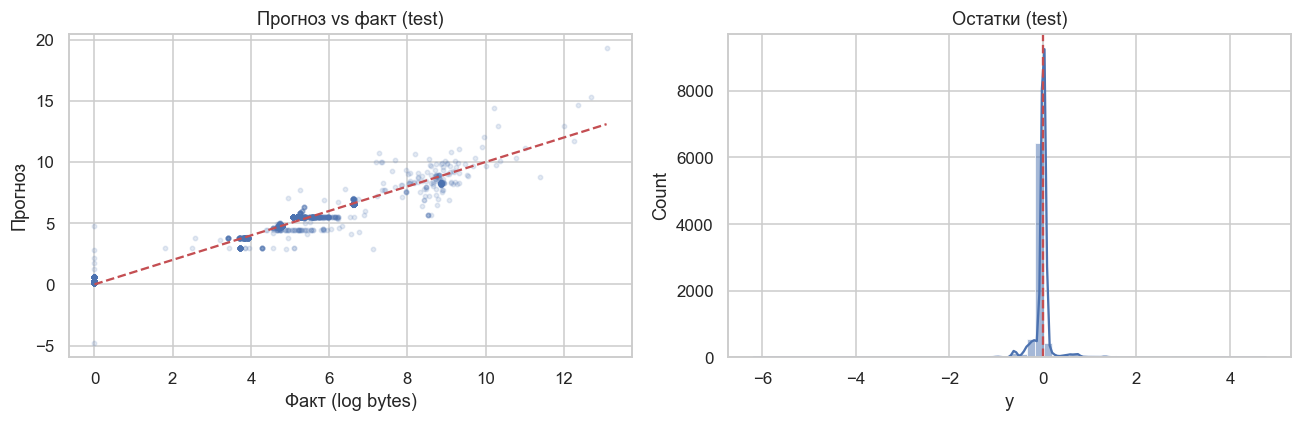

In [9]:
pred = baseline.predict(X_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test, pred, alpha=0.15, s=8)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Факт (log bytes)")
ax[0].set_ylabel("Прогноз"); ax[0].set_title("Прогноз vs факт (test)")
sns.histplot(y_test - pred, bins=60, kde=True, ax=ax[1])
ax[1].axvline(0, color="r", ls="--"); ax[1].set_title("Остатки (test)")
plt.tight_layout()

## 5. Откуда берётся θ — математика под капотом
Линейная модель: $\hat{y}=X\theta$. Ищем θ, минимизируя MSE $J(\theta)=\tfrac1m\lVert X\theta-y\rVert^2$.

**Способ 1 — нормальное уравнение** (точная формула): $\;\hat{\theta}=(X^\top X)^{-1}X^\top y$.

**Способ 2 — градиентный спуск** (итеративно против градиента):
$$\nabla_\theta J=\tfrac{2}{m}X^\top(X\theta-y),\qquad \theta\leftarrow\theta-\eta\,\nabla_\theta J$$

Берём компактный набор хорошо обусловленных признаков и убеждаемся: оба способа дают **одну** θ
(и совпадают со sklearn).

In [10]:
demo = ["log_fwd_pkts_tot", "log_bwd_pkts_tot", "log_flow_duration",
        "log_fwd_header_size_tot", "log_bwd_header_size_tot"]
Xs = StandardScaler().fit_transform(X_train[demo])
Xb = np.c_[np.ones(len(Xs)), Xs]              # столбец единиц = bias θ₀
yv = y_train.values.reshape(-1, 1)

theta_normal  = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ yv      # нормальное уравнение
lin = LinearRegression().fit(Xs, y_train)                # sklearn для сверки
theta_sklearn = np.r_[lin.intercept_, lin.coef_].reshape(-1, 1)
print(f"cond(XᵀX) = {np.linalg.cond(Xb.T @ Xb):.0f}  (хорошо обусловлена — формула устойчива)")
print(f"Макс. расхождение θ (нормальное vs sklearn): {np.abs(theta_normal - theta_sklearn).max():.2e}")

cond(XᵀX) = 448  (хорошо обусловлена — формула устойчива)
Макс. расхождение θ (нормальное vs sklearn): 2.41e-13


Макс. расхождение θ (град. спуск vs нормальное): 6.67e-04


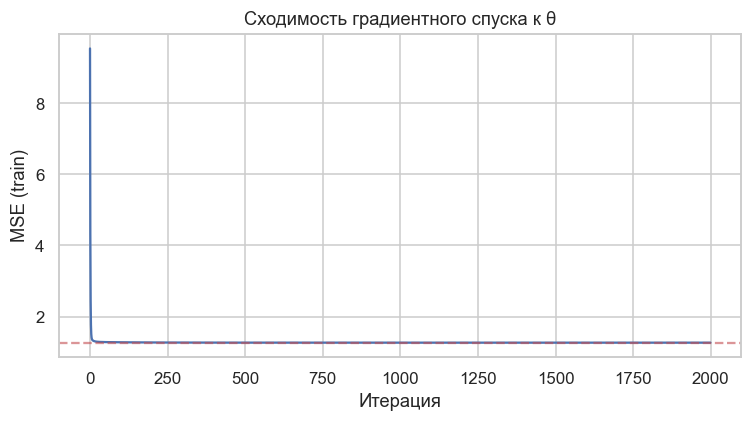

In [11]:
eta, n_iter, m = 0.2, 2000, len(Xb)        # batch gradient descent руками
theta_gd = np.zeros((Xb.shape[1], 1)); cost = []
for _ in range(n_iter):
    grad = (2/m) * Xb.T @ (Xb @ theta_gd - yv)
    theta_gd -= eta * grad
    cost.append(float(np.mean((Xb @ theta_gd - yv) ** 2)))
print(f"Макс. расхождение θ (град. спуск vs нормальное): {np.abs(theta_gd - theta_normal).max():.2e}")

plt.figure(figsize=(7, 4)); plt.plot(cost)
plt.xlabel("Итерация"); plt.ylabel("MSE (train)")
plt.title("Сходимость градиентного спуска к θ")
plt.axhline(cost[-1], color="r", ls="--", alpha=0.6); plt.tight_layout()

Интерпретация θ (масштабированные признаки → больший |θ| = сильнее влияет на log-объём):

In [12]:
pd.Series(lin.coef_, index=demo).sort_values(key=abs, ascending=False).round(3).to_frame("θ")

,θ
log_bwd_pkts_tot,1.600
log_bwd_header_size_tot,-0.787
log_flow_duration,-0.458
log_fwd_header_size_tot,0.426
log_fwd_pkts_tot,-0.278


## 6. Полином — взаимодействия и переобучение
Объём зависит от пакетов **и** сервиса вместе — добавим квадраты и произведения через
`PolynomialFeatures`. Число признаков растёт в разы; смотрим на тест и на разрыв train↔test.

In [13]:
poly = lambda deg, est: Pipeline([
    ("pre", pre), ("poly", PolynomialFeatures(deg, include_bias=False)),
    ("sc", StandardScaler()), ("est", est)])

for deg in (2, 3):
    m_ = poly(deg, LinearRegression()).fit(X_train, y_train)
    nf = m_.named_steps["poly"].n_output_features_
    tr = r2_score(y_train, m_.predict(X_train))
    s  = evaluate(m_, f"Poly deg={deg} без штрафа ({nf} фич)")
    s["R2_train"] = tr
    scores.append({k: s[k] for k in ["model", "MAE", "RMSE", "R2"]})
    print(f'{s["model"]:32s} R2_train={tr:.3f}  R2_test={s["R2"]:.3f}')
pd.DataFrame(scores).round(3)

Poly deg=2 без штрафа (464 фич)  R2_train=0.995  R2_test=-11.098


Poly deg=3 без штрафа (4959 фич) R2_train=0.997  R2_test=-7481914780.068


,model,MAE,RMSE,R2
0,Linear (baseline),0.087,0.275,9.600000e-01
1,Poly deg=2 без штрафа (464 фич),0.095,4.767,-1.109800e+01
2,Poly deg=3 без штрафа (4959 фич),3750.859,118546.884,-7.481915e+09


## 7. Регуляризация — штраф за сложность
К ошибке добавляем штраф за размер коэффициентов (α подбираем кросс-валидацией на train):

- **Ridge (L2):** $\;J=\text{MSE}+\alpha\sum_j\theta_j^2\;$ — сжимает коэффициенты, гасит мультиколлинеарность.
- **Lasso (L1):** $\;J=\text{MSE}+\alpha\sum_j|\theta_j|\;$ — **зануляет** лишние → отбор признаков.
- **ElasticNet:** $\;J=\text{MSE}+\alpha\big(r\sum|\theta_j|+(1-r)\sum\theta_j^2\big)\;$ — смесь L1 и L2.

Регуляризуем полином degree 2.

In [14]:
alphas = np.logspace(-3, 2, 12)
ridge = poly(2, RidgeCV(alphas=alphas)).fit(X_train, y_train)
lasso = poly(2, LassoCV(alphas=alphas, max_iter=10000, random_state=RS, n_jobs=-1)).fit(X_train, y_train)
enet  = poly(2, ElasticNetCV(alphas=alphas, l1_ratio=[.2, .5, .8],
                             max_iter=10000, random_state=RS, n_jobs=-1)).fit(X_train, y_train)
for m_, n_ in [(ridge, "Poly2 + Ridge (L2)"), (lasso, "Poly2 + Lasso (L1)"),
               (enet,  "Poly2 + ElasticNet")]:
    scores.append(evaluate(m_, n_))
print("Выбранные α: Ridge=%.4f | Lasso=%.4f | ElasticNet=%.4f (l1_ratio=%.1f)" % (
    ridge.named_steps["est"].alpha_, lasso.named_steps["est"].alpha_,
    enet.named_steps["est"].alpha_, enet.named_steps["est"].l1_ratio_))
pd.DataFrame(scores).round(3).sort_values("RMSE").reset_index(drop=True)

Выбранные α: Ridge=100.0000 | Lasso=0.0010 | ElasticNet=0.0231 (l1_ratio=0.2)


,model,MAE,RMSE,R2
0,Poly2 + Ridge (L2),0.033,0.120,9.920000e-01
1,Poly2 + Lasso (L1),0.033,0.120,9.920000e-01
2,Poly2 + ElasticNet,0.043,0.133,9.910000e-01
3,Linear (baseline),0.087,0.275,9.600000e-01
4,Poly deg=2 без штрафа (464 фич),0.095,4.767,-1.109800e+01
5,Poly deg=3 без штрафа (4959 фич),3750.859,118546.884,-7.481915e+09


Lasso обнулил 387 из 464 полиномиальных признаков (83%) → встроенный feature selection


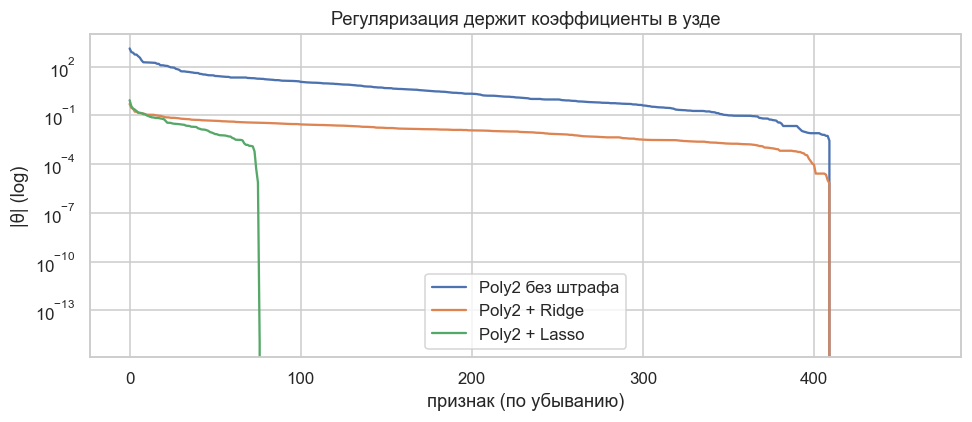

In [15]:
# Lasso как отбор признаков + сравнение размаха коэффициентов
lc = lasso.named_steps["est"].coef_
print(f"Lasso обнулил {int((lc==0).sum())} из {len(lc)} полиномиальных признаков "
      f"({(lc==0).mean()*100:.0f}%) → встроенный feature selection")

plain2 = poly(2, LinearRegression()).fit(X_train, y_train)
plt.figure(figsize=(9, 4))
plt.plot(np.sort(np.abs(plain2.named_steps["est"].coef_))[::-1], label="Poly2 без штрафа")
plt.plot(np.sort(np.abs(ridge.named_steps["est"].coef_))[::-1], label="Poly2 + Ridge")
plt.plot(np.sort(np.abs(lasso.named_steps["est"].coef_))[::-1], label="Poly2 + Lasso")
plt.yscale("log"); plt.ylabel("|θ| (log)"); plt.xlabel("признак (по убыванию)")
plt.title("Регуляризация держит коэффициенты в узде"); plt.legend(); plt.tight_layout()

## 8. Диагностика — кривые обучения
Слева полином без штрафа, справа — выбранная регуляризованная модель.
Большой разрыв train↔val = переобучение; кривые сходятся низко = здоровая модель.

Лучшая модель по RMSE: Poly2 + Ridge (L2)


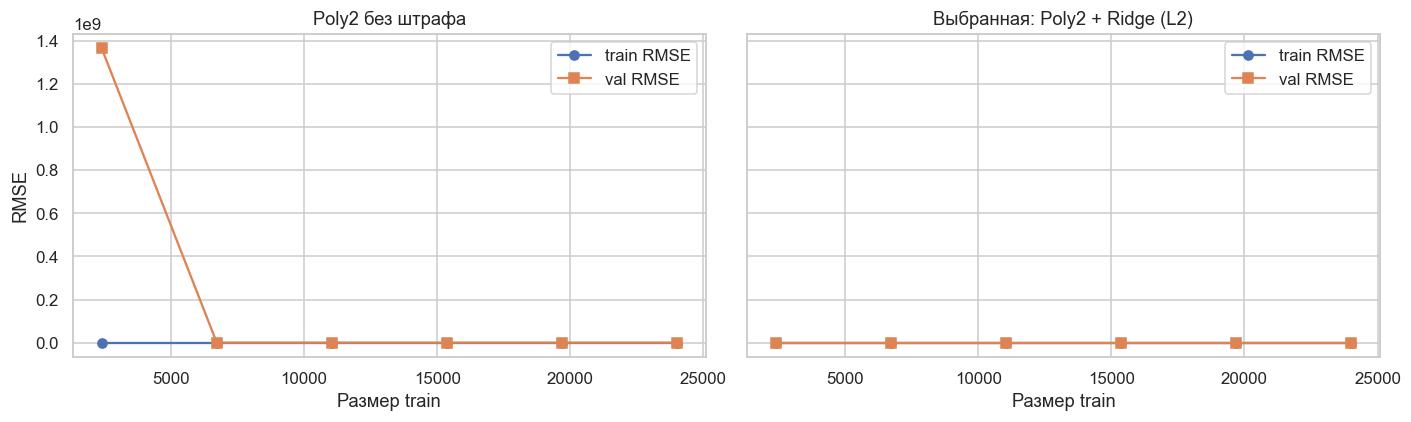

In [16]:
best_name = pd.DataFrame(scores).sort_values("RMSE").iloc[0]["model"]
models_map = {"Linear (baseline)": baseline, "Poly2 + Ridge (L2)": ridge,
              "Poly2 + Lasso (L1)": lasso, "Poly2 + ElasticNet": enet}
best_model = models_map.get(best_name, ridge)
print("Лучшая модель по RMSE:", best_name)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for a, (mdl, ttl) in zip(ax, [(poly(2, LinearRegression()), "Poly2 без штрафа"),
                              (best_model, f"Выбранная: {best_name}")]):
    sizes, tr, va = learning_curve(mdl, X_train, y_train, cv=4,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6), random_state=RS, n_jobs=-1)
    a.plot(sizes, -tr.mean(1), "o-", label="train RMSE")
    a.plot(sizes, -va.mean(1), "s-", label="val RMSE")
    a.set_title(ttl); a.set_xlabel("Размер train"); a.legend()
ax[0].set_ylabel("RMSE"); plt.tight_layout()

## 9. Вердикт — можно ли верить?

In [17]:
final = pd.DataFrame(scores).sort_values("RMSE").reset_index(drop=True)
best = final.iloc[0]; rmse_log = best["RMSE"]
factor = np.exp(rmse_log)            # перевод из log-шкалы в «во сколько раз» типично ошибаемся
print(f"Лучшая модель: {best['model']}")
print(f"RMSE = {rmse_log:.3f} в log-шкале  →  типичная ошибка ≈ ×{factor:.2f} по объёму байт")
print(f"R² = {best['R2']:.3f}  (объясняет {best['R2']*100:.0f}% разброса log-объёма)")
print(f"std целевой y = {y_test.std():.3f}; RMSE = {rmse_log/y_test.std()*100:.0f}% от разброса цели")
final.round(3)

Лучшая модель: Poly2 + Ridge (L2)
RMSE = 0.120 в log-шкале  →  типичная ошибка ≈ ×1.13 по объёму байт
R² = 0.992  (объясняет 99% разброса log-объёма)
std целевой y = 1.371; RMSE = 9% от разброса цели


,model,MAE,RMSE,R2
0,Poly2 + Ridge (L2),0.033,0.120,9.920000e-01
1,Poly2 + Lasso (L1),0.033,0.120,9.920000e-01
2,Poly2 + ElasticNet,0.043,0.133,9.910000e-01
3,Linear (baseline),0.087,0.275,9.600000e-01
4,Poly deg=2 без штрафа (464 фич),0.095,4.767,-1.109800e+01
5,Poly deg=3 без штрафа (4959 фич),3750.859,118546.884,-7.481915e+09


In [18]:
# Где модель врёт сильнее всего — топ-5 остатков (в байтах)
pred = best_model.predict(X_test)
out = X_test.copy()
out["факт_байт"]    = np.expm1(y_test).round().astype(int)
out["прогноз_байт"] = np.expm1(pred).round().astype(int)
out["|ошибка_log|"] = np.abs(y_test - pred)
cols = ["proto", "service", "log_total_pkts", "факт_байт", "прогноз_байт", "|ошибка_log|"]
out.sort_values("|ошибка_log|", ascending=False)[cols].head(5).round(2)

,proto,service,log_total_pkts,факт_байт,прогноз_байт,|ошибка_log|
1,udp,-,6.74,483067,23270,3.03
7212,tcp,-,1.61,0,-1,2.88
14607,udp,-,4.41,10335,147412,2.66
24017,udp,-,0.69,5,43,2.00
38537,udp,dhcp,0.69,244,1589,1.87


### 🎯 Вывод
- **Базовая** линейная модель на лог-признаках уже объясняет большую часть разброса log-объёма —
  поведение потока действительно несёт информацию о его «весе».
- **Полином** ловит взаимодействия (объём ↔ пакеты ↔ сервис), но без штрафа склонен к переобучению.
- **Регуляризация** даёт лучший и устойчивый результат; **Lasso** дополнительно зануляет лишние признаки
  (отбор фич), а кривые обучения сходятся — переобучения нет.

**Можно ли верить?** Для оценки порядка объёма и детекта аномалий — да: типичная ошибка ≈ ×(фактор) по байтам.
Но модель **систематически врёт на редких «тяжёлых» потоках** (топ-остатки — крупные передачи): мы намеренно
скрыли от неё размеры пакетов, поэтому точный объём гигантов она не угадывает.
Не «модель хорошая», а «надёжна для типичных потоков и осторожна на крупных выбросах».